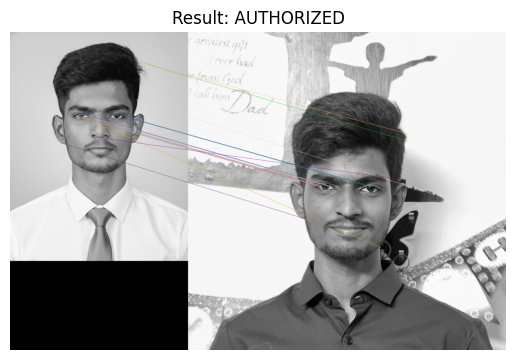

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Load images
img1 = cv2.imread("test1.jpeg", 0)  # enrolled face
img2 = cv2.imread("face1.jpeg", 0)  # input face

# Step 2: ORB feature detector
orb = cv2.ORB_create()

# Step 3: Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

# Step 4: Match features
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Step 5: Sort matches (best first)
matches = sorted(matches, key=lambda x: x.distance)

# Step 6: Decision (IMPORTANT)
match_score = len(matches)

if match_score > 30:
    result = "AUTHORIZED"
else:
    result = "ACCESS DENIED"

# Step 7: Draw matches
img_match = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=2)

# Step 8: Display
plt.imshow(img_match, cmap='gray')
plt.title(f"Result: {result}")
plt.axis('off')
plt.show()

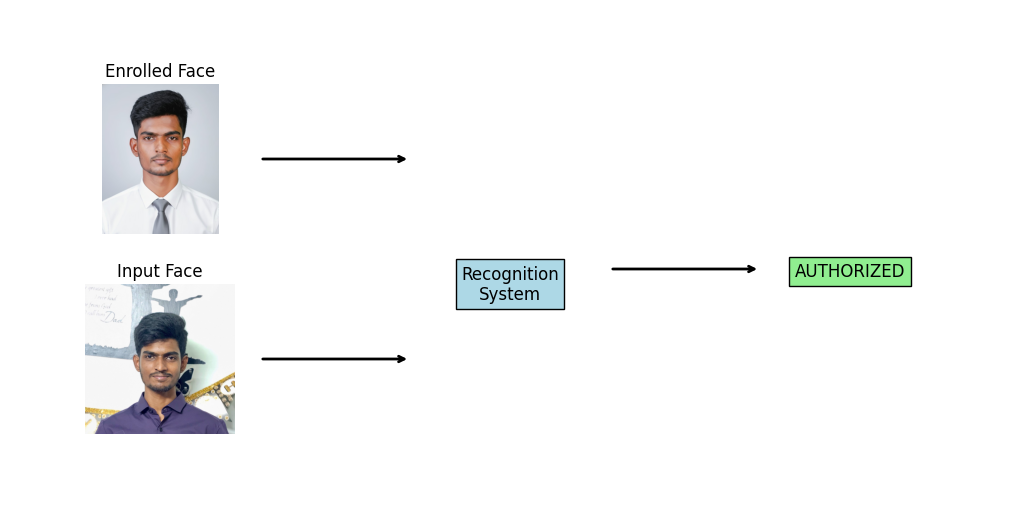

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread("test1.jpeg")
img2 = cv2.imread("face1.jpeg")

if img1 is None or img2 is None:
    print("Error: Check image path")
    exit()

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# ORB Matching (same logic)
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

result = "AUTHORIZED" if len(matches) > 30 else "ACCESS DENIED"

# ---------------- LAYOUT ----------------
fig = plt.figure(figsize=(10,5))

# Faces
ax1 = fig.add_axes([0.05, 0.55, 0.2, 0.3])
ax1.imshow(img1)
ax1.set_title("Enrolled Face")
ax1.axis('off')

ax2 = fig.add_axes([0.05, 0.15, 0.2, 0.3])
ax2.imshow(img2)
ax2.set_title("Input Face")
ax2.axis('off')

# System Box
ax3 = fig.add_axes([0.4, 0.35, 0.2, 0.2])
ax3.text(0.5, 0.5, "Recognition\nSystem",
         ha='center', va='center',
         bbox=dict(facecolor='lightblue', edgecolor='black'),
         fontsize=12)
ax3.axis('off')

# Result Box
color = 'lightgreen' if result == "AUTHORIZED" else 'salmon'

ax4 = fig.add_axes([0.75, 0.4, 0.18, 0.15])
ax4.text(0.5, 0.5, result,
         ha='center', va='center',
         bbox=dict(facecolor=color, edgecolor='black'),
         fontsize=12)
ax4.axis('off')

# ---------------- PERFECT ARROWS ----------------

# Create overlay axis for arrows (THIS is the trick 🔥)
ax_arrow = fig.add_axes([0,0,1,1])
ax_arrow.axis('off')

# Enrolled → System
ax_arrow.annotate('', xy=(0.4, 0.7), xytext=(0.25, 0.7),
                  arrowprops=dict(arrowstyle='->', lw=2))

# Input → System
ax_arrow.annotate('', xy=(0.4, 0.3), xytext=(0.25, 0.3),
                  arrowprops=dict(arrowstyle='->', lw=2))

# System → Result
ax_arrow.annotate('', xy=(0.75, 0.48), xytext=(0.6, 0.48),
                  arrowprops=dict(arrowstyle='->', lw=2))

plt.show()

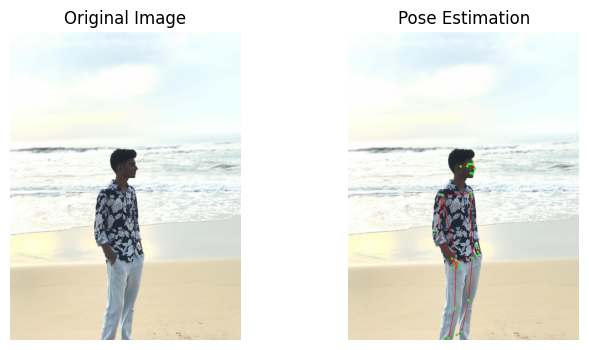

In [2]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("test2.jpeg")  # change your image path
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# MediaPipe setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(static_image_mode=True)

# Process image
results = pose.process(image_rgb)

# Copy image for drawing
output = image_rgb.copy()

# Draw skeleton
if results.pose_landmarks:
    mp_drawing.draw_landmarks(
        output,
        results.pose_landmarks,
        mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,255,0), thickness=3, circle_radius=3),
        mp_drawing.DrawingSpec(color=(255,0,0), thickness=2)
    )

# Display (EXACT record format)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Pose Estimation")
plt.axis('off')

plt.show()